## First Neural Network on MNIST

Goal: build a simple multilayer perceptron (MLP) in PyTorch and understand:
- input shape
- forward pass
- loss computation
- basic training loop

### Steps
1. Load MNIST
2. Inspect one batch
3. Flatten images
4. Build a simple MLP
5. Run a forward pass
6. Compute loss
7. Write a manual training loop

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


### Load MNIST

### What the data looks like
- Each MNIST image has shape `(1, 28, 28)`
- For an MLP, images are flattened into vectors of size `784`
- The model outputs `10` logits, one for each digit class

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Inspect one batch:

In [5]:
images, labels = next(iter(train_loader))

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("first labels:", labels[:10])

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
first labels: tensor([8, 6, 1, 9, 4, 8, 8, 9, 1, 2])


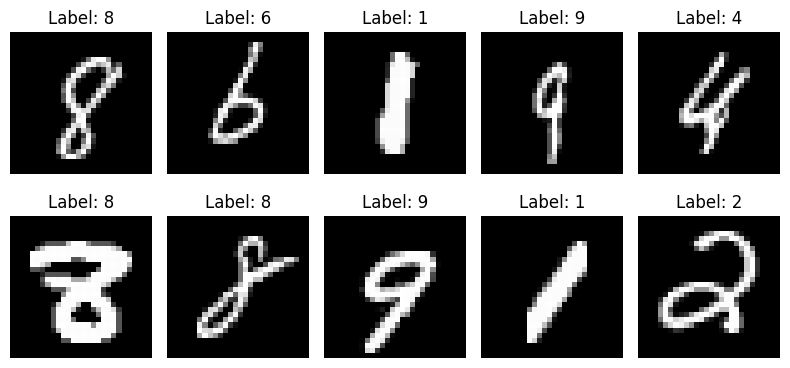

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(8, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

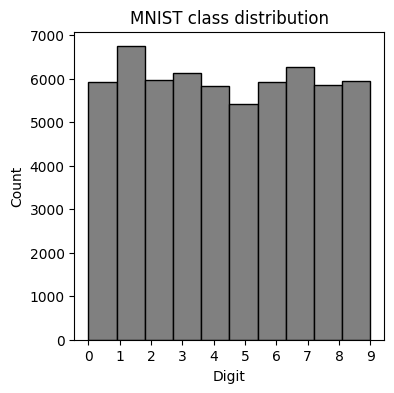

In [7]:
all_labels = train_dataset.targets

plt.figure(figsize=(4,4))
plt.hist(all_labels.numpy(), bins=10, edgecolor="black", color='grey')
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("MNIST class distribution")
plt.show()

MLP expects vectors, not 2D images so we need to flatten them:

In [8]:
flat_images = images.view(images.size(0), -1)
print("flattened shape:", flat_images.shape)

flattened shape: torch.Size([64, 784])


### Build a simple MLP

We will start with simply: nn.Linear → ReLU → nn.Linear

In [9]:
model = nn.Sequential(
    nn.Flatten(), # no need to flatten manually
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # final output size is 10 because digits are 0-9
).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


### Run a forward pass

We move tensors to a device (CPU/GPU) so that computations happen on that device.

All tensors and the model must be on the same device; otherwise, PyTorch will raise an error.

Using a GPU accelerates heavy operations like matrix multiplications during the forward pass.

In [10]:
images, labels = images.to(device), labels.to(device)

logits = model(images)
print("logits shape:", logits.shape)
print(logits[:2])

logits shape: torch.Size([64, 10])
tensor([[ 0.0662,  0.0047,  0.0147,  0.1422, -0.0717,  0.1033,  0.0121,  0.0268,
          0.0534, -0.1555],
        [ 0.0139, -0.0570, -0.0579,  0.1184,  0.0017,  0.0924, -0.0130, -0.0281,
          0.0125, -0.1614]], device='mps:0', grad_fn=<SliceBackward0>)


Output size intepretation:
- one row per image (batch size = 64)
- one score per class

Outputs are logits, but we can to turn them into probabilities for intuition:

In [11]:
probs = torch.softmax(logits, dim=1)
print(probs[:2])
print(probs[:2].sum(dim=1))

tensor([[0.1044, 0.0982, 0.0992, 0.1127, 0.0910, 0.1084, 0.0989, 0.1004, 0.1031,
         0.0837],
        [0.1019, 0.0949, 0.0949, 0.1131, 0.1007, 0.1102, 0.0992, 0.0977, 0.1018,
         0.0855]], device='mps:0', grad_fn=<SliceBackward0>)
tensor([1.0000, 1.0000], device='mps:0', grad_fn=<SumBackward1>)


Each row sums to 1.

We can also inspect predictions:

In [12]:
preds = probs.argmax(dim=1)
print("predictions:", preds[:10])
print("true labels:", labels[:10])

predictions: tensor([3, 3, 3, 0, 5, 5, 0, 5, 3, 3], device='mps:0')
true labels: tensor([8, 6, 1, 9, 4, 8, 8, 9, 1, 2], device='mps:0')


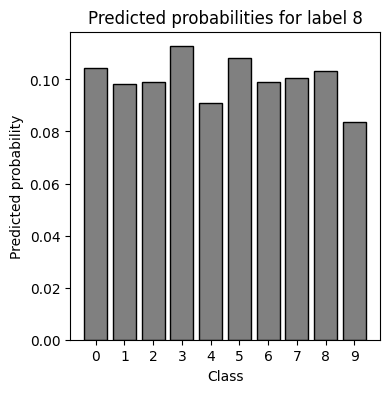

In [13]:
idx = 0
plt.figure(figsize=(4, 4))
plt.bar(range(10), probs[idx].detach().cpu().numpy(), color='grey', edgecolor='black')
plt.xticks(range(10))
plt.xlabel("Class")
plt.ylabel("Predicted probability")
plt.title(f"Predicted probabilities for label {labels[idx].item()}")
plt.show()

It's ok: it's the initial forward pass for predictions are bad.

### Compute loss

For multiclass classification, we use cross-entropy:

In [14]:
criterion = nn.CrossEntropyLoss()
loss = criterion(logits, labels)

print("loss:", loss.item())

loss: 2.3104348182678223


Important: CrossEntropyLoss expects raw logits because it internally applies log-softmax for numerical stability. Applying softmax beforehand would be redundant and can lead to incorrect gradients.

### Inspecting Gradients After `loss.backward()`
Goal: see that each trainable parameter receives a gradient.

In [16]:
# Take one batch
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

# Forward pass
logits = model(images)
loss = criterion(logits, labels)

# Zero old gradients
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer.zero_grad()

# Backward pass
loss.backward()

print("Loss:", loss.item())
print()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(name)
        print("  weight shape:", tuple(param.shape))
        print("  grad shape:  ", tuple(param.grad.shape))
        print("  grad mean:   ", param.grad.mean().item())
        print("  grad norm:   ", param.grad.norm().item())
        print()

Loss: 2.319528102874756

1.weight
  weight shape: (128, 784)
  grad shape:   (128, 784)
  grad mean:    8.749587868805975e-05
  grad norm:    0.5355762243270874

1.bias
  weight shape: (128,)
  grad shape:   (128,)
  grad mean:    0.0006613835575990379
  grad norm:    0.044652875512838364

3.weight
  weight shape: (10, 128)
  grad shape:   (10, 128)
  grad mean:    1.09157560768125e-09
  grad norm:    0.21567238867282867

3.bias
  weight shape: (10,)
  grad shape:   (10,)
  grad mean:    1.4342367293807001e-08
  grad norm:    0.10621721297502518



Do Weights Actually Change? Compare weights before and after `optimizer.step()`.

In [17]:
images2, labels2 = next(iter(train_loader))
images2 = images2.to(device)
labels2 = labels2.to(device)

optimizer.zero_grad()
logits2 = model(images2)
loss2 = criterion(logits2, labels2)
loss2.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, "grad norm on second batch:", param.grad.norm().item())

1.weight grad norm on second batch: 0.6126747131347656
1.bias grad norm on second batch: 0.05796496197581291
3.weight grad norm on second batch: 0.2606874406337738
3.bias grad norm on second batch: 0.15744833648204803


In [18]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()
logits = model(images)
loss = criterion(logits, labels)
loss.backward()

before = model[1].weight.detach().clone()   # first Linear layer weights
optimizer.step()
after = model[1].weight.detach().clone()

weight_change = (after - before).norm().item()
print("Weight change norm after one optimizer step:", weight_change)

Weight change norm after one optimizer step: 0.23574107885360718


What training actually does:

- `loss.backward()` computes gradients of the loss with respect to each parameter.

- These gradients tell us how each weight should change to reduce the loss.

- `optimizer.step()` then updates the parameters using those gradients.

As a result, over epochs, training loss decreases and training accuracy increases.

### Minimal manual training loop

Monitor not only loss but also classification performance during training.

In [19]:
num_epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - loss: {epoch_loss:.4f} - acc: {epoch_acc:.4f}")

Epoch 1/10 - loss: 0.3431 - acc: 0.9065
Epoch 2/10 - loss: 0.1538 - acc: 0.9560
Epoch 3/10 - loss: 0.1068 - acc: 0.9691
Epoch 4/10 - loss: 0.0808 - acc: 0.9758
Epoch 5/10 - loss: 0.0636 - acc: 0.9810
Epoch 6/10 - loss: 0.0513 - acc: 0.9850
Epoch 7/10 - loss: 0.0421 - acc: 0.9870
Epoch 8/10 - loss: 0.0337 - acc: 0.9906
Epoch 9/10 - loss: 0.0283 - acc: 0.9919
Epoch 10/10 - loss: 0.0235 - acc: 0.9933


Quick evaluation loop:

In [27]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test accuracy: {test_acc:.4f}")

Test accuracy: 0.9786


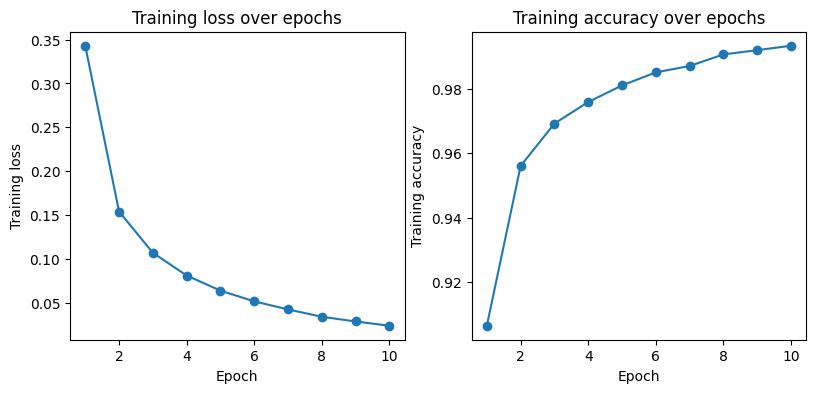

In [25]:
f, ax = plt.subplots(1,2, figsize=(9.5, 4))
ax[0].plot(range(1, num_epochs + 1), train_losses, marker="o")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training loss")
ax[0].set_title("Training loss over epochs")

ax[1].plot(range(1, num_epochs + 1), train_accuracies, marker="o")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Training accuracy")
ax[1].set_title("Training accuracy over epochs")
plt.show()

## Final Takeaways

### What is a neural network?
- A neural network is a composition of layers that transform input data into output predictions.
- Each layer applies a learned transformation parameterized by weights and biases.

### Forward pass
- Data flows through the network to produce outputs (logits).
- These logits represent unnormalized scores for each class.

### Loss function
- The loss measures how far predictions are from true labels.
- For classification, `CrossEntropyLoss` is used and expects raw logits (no softmax needed).

### Backpropagation
- `loss.backward()` computes gradients of the loss with respect to each parameter.
- Gradients indicate how each weight should change to reduce the loss.

### Optimization
- `optimizer.step()` updates the weights using the computed gradients.
- Training progressively reduces loss and improves accuracy.

### Mini-batch training
- Gradients are computed on small random batches of data.
- This introduces noise but makes training efficient and effective.

### What training actually does
- Forward pass → compute predictions  
- Loss → measure error  
- Backward pass → compute gradients  
- Optimizer → update weights  

### Key observations from this experiment
- Loss decreases steadily over epochs.
- Accuracy increases as the model learns.
- Gradients differ across batches (stochastic learning).
- Weights change after each optimizer step.

### Result
- A simple MLP achieves ~99% training accuracy on MNIST.
- This demonstrates how basic neural networks learn from data.